# Stage 3 — Hydrological Connectivity (Mole Creek prototype)

Answers a different question from Stage 2: not "where is karst?" but
"where could something happening at the surface actually reach the
karst?"

**Inputs:**
- `KPROXCATCH` — Karst Atlas field for proximal (allogenic) catchments
  draining directly into karst. Its A-D values classify *the karst area
  it drains into*, not the connectivity strength of the catchment
  itself — treated here as presence/absence, not an ordinal score.
- `KDISTCATCH` — distal catchments (whole upstream river catchment),
  scored lower (less direct effect, per the data dictionary).
- DEM-derived flow accumulation (WhiteboxTools) — an independent
  physical check against the Atlas classification.
- The exposure type from Stage 2.

**Connectivity scoring revised after review** (see `src/karst.py`):
exposed and covered karst originally scored identically (both
autogenic). Covered karst has a protective non-karst cap between the
surface and the karst itself — EPIK's Protective Cover (P) factor
(discussed when EPIK/COP were compared and set aside in this project's
Framework section) treats that cover as reducing vulnerability, not
being neutral to it. Revised: exposed=3 (no buffering), covered=2
(still autogenic, but buffered), interstratal=1 (not autogenic at all
per the data dictionary — its recharge depends on an external
catchment).

**Boundary note:** the Mole Creek study boundary (Stage 0) was
originally just the union of karst polygons, 99.9997% covered by
karst/catchment features with no surrounding land -- fixed with a 3km
buffer before this notebook could produce anything meaningful.

In [1]:
from pathlib import Path
import os
import sys
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import whitebox

sys.path.insert(0, str(Path("..") / "src"))
from karst import add_connectivity, rasterize_max

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

# Reads Stage 2's output, not Stage 1's -- each stage now has its own file
karst_mc = gpd.read_file(str(outpath / "karst_mc_susceptibility_EPSG7855.gpkg"))
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

## 3.1 Atlas-based connectivity score

Combines three signals via `add_connectivity()`, taking the **max** per
polygon (a polygon can be karst itself *and* separately flagged as a
catchment for an adjacent karst area — confirmed in the real data).

In [2]:
add_connectivity(karst_mc)

print("Connectivity score distribution (polygon count):")
print(karst_mc["connectivity"].value_counts().sort_index())
print()
print("Which component drove each score, by exposure type:")
print(pd.crosstab(karst_mc["connectivity"], karst_mc["exposure_type"]))

karst_mc.to_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg", driver="GPKG")

Connectivity score distribution (polygon count):
connectivity
0     5
2    18
3    67
Name: count, dtype: int64

Which component drove each score, by exposure type:
exposure_type  covered  exposed  interstratal  non-karst
connectivity                                            
0                    0        0             0          5
2                   18        0             0          0
3                    0       45            10         12


## 3.2 Rasterise onto the Stage 1 DEM template

Any cell not covered by a karst/catchment polygon at all correctly falls back to 0 (real background land, now that the boundary includes it). Uses `rasterize_max()` -- see Stage 2's note on why.

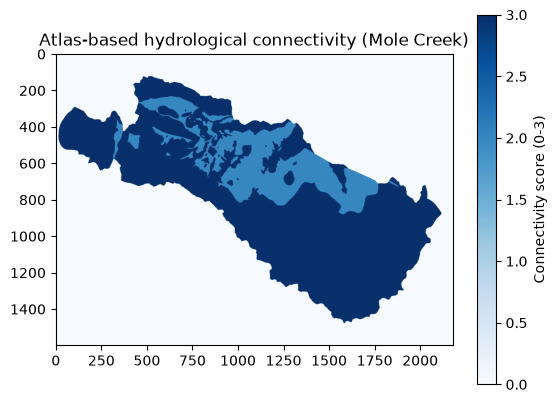

In [3]:
with rasterio.open(str(outpath / "dem_mc_EPSG7855.tif")) as dem_src:
    template_transform = dem_src.transform
    template_shape = (dem_src.height, dem_src.width)
    template_crs = dem_src.crs

connectivity_raster = rasterize_max(karst_mc, "connectivity", template_shape, template_transform)

profile = {
    "driver": "GTiff", "height": template_shape[0], "width": template_shape[1],
    "count": 1, "dtype": "uint8", "crs": template_crs, "transform": template_transform, "nodata": 255,
}
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif", "w", **profile) as dst:
    dst.write(connectivity_raster, 1)

plt.imshow(connectivity_raster, cmap="Blues")
plt.title("Atlas-based hydrological connectivity (Mole Creek)")
plt.colorbar(label="Connectivity score (0-3)")
plt.show()

## 3.3 DEM-derived flow accumulation

Via WhiteboxTools: fill depressions, compute D8 flow accumulation. No
PyQGIS involved.

**Fixed after review:** the original version also called `d8_pointer`
and never used its output -- `d8_flow_accumulation` computes flow
direction internally from the filled DEM directly, so the separate
pointer step was dead code. Removed.

In [4]:
wbt = whitebox.WhiteboxTools()
wbt.set_working_dir(str(outpath))
wbt.verbose = False

wbt.fill_depressions("dem_mc_EPSG7855.tif", "dem_mc_filled.tif")
wbt.d8_flow_accumulation("dem_mc_filled.tif", "flow_accum_mc_EPSG7855.tif", out_type="cells")

with rasterio.open(outpath / "flow_accum_mc_EPSG7855.tif") as src:
    flow_accum = src.read(1)
    flow_nodata = src.nodata

print("Flow accumulation computed:", flow_accum.shape)

Flow accumulation computed: (1599, 2178)


## 3.4 Compare: do DEM-derived drainage channels coincide with Atlas connectivity?

A raw mean over broad zones washes out the signal (flow accumulation is
dominated by a handful of narrow channel cells; most of any zone is
hillslope with near-1 accumulation). Instead: threshold flow
accumulation into a channel network (top 5%), then check what fraction
of channel cells falls within Atlas-mapped connectivity zones vs.
background — plus a visual overlay, since the statistic alone doesn't
tell the whole story.

Channel network: top 5% by flow accumulation (threshold=165 cells)
Connectivity=0: 4.6% of cells are channel cells (n=652116)
Connectivity=2: 7.6% of cells are channel cells (n=253331)
Connectivity=3: 4.6% of cells are channel cells (n=942963)


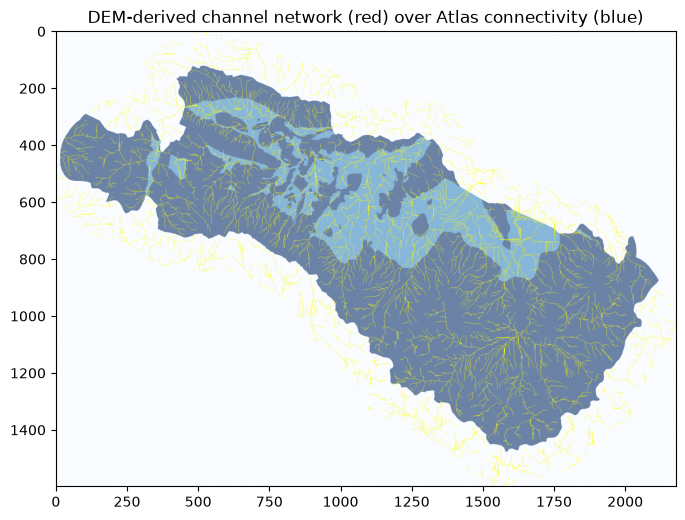

In [5]:
valid = flow_accum != flow_nodata
channel_threshold = np.percentile(flow_accum[valid], 95)
is_channel = valid & (flow_accum >= channel_threshold)
print(f"Channel network: top 5% by flow accumulation (threshold={channel_threshold:.0f} cells)")

for level in sorted(np.unique(connectivity_raster)):
    mask_level = (connectivity_raster == level) & valid
    if mask_level.sum() > 0:
        pct_channel = is_channel[mask_level].mean() * 100
        print(f"Connectivity={level}: {pct_channel:.1f}% of cells are channel cells (n={mask_level.sum()})")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(connectivity_raster, cmap="Blues", alpha=0.6)
ax.imshow(np.where(is_channel, 1, np.nan), cmap="autumn_r")
plt.title("DEM-derived channel network (red) over Atlas connectivity (blue)")
plt.show()

## Result: a weak, non-contradictory signal

The channel-density check comes out close across classes (roughly
4-5% either way), a weak signal. That's a legitimate result to report
as-is: the revised workflow plan explicitly doesn't require
sophisticated statistical validation here, just a plausibility check.
The visual overlay is more informative than the summary statistic for
this particular check.

**Note on what this notebook doesn't do:** the three-layer framework in
the scope doc describes karst susceptibility, hydrological connectivity,
and land-use pressure as three independent factors. In practice,
connectivity comes out close to a binary mask at Mole Creek (most karst
polygons score the maximum) — flagged honestly in Stage 4 rather than
overstated here. Statewide (Stage 7), connectivity does show genuine
variation, since not every karst area has a proximal catchment tagged.

## Stage 3 outputs

- `connectivity_atlas_mc_EPSG7855.tif` — Atlas-based connectivity raster (0-3)
- `flow_accum_mc_EPSG7855.tif` — DEM-derived flow accumulation
- `karst_mc_connectivity_EPSG7855.gpkg` — Stage 2's data plus connectivity
  columns (its own file; the final, complete Mole Creek karst vector used
  by Stages 4, 6, and 8)

**Next (Stage 4):** combine Stage 2 (susceptibility) × Stage 3
(connectivity) into intrinsic karst vulnerability — still Mole Creek
prototype, before Stage 5 introduces land-use pressure.